# B17 · FlexTab and GTAlign: what can a representation reuse?

<p class="subtitle">Research bridge · elective · trace the adaptation boundary.</p>

[B16](https://avistian.github.io/relational/lessons/b16-autograble-graph-selection.html) asked which graph to construct for a task. Once we have chosen useful inputs, another question appears: **can we encode them once and reuse the result for another task?** This matters to the mission because a relational foundation model must justify both its predictive benefit and the work required to adapt it.

Your tangible win: trace two target tasks through one encoder, identify exactly when its cache becomes stale, and explain which GTAlign weights change on a new domain. Recall [B07’s semantic features](https://avistian.github.io/relational/lessons/b07-semantic-transfer.html), [B11’s structural encoders](https://avistian.github.io/relational/lessons/b11-supervised-relational-baselines.html), and [B12’s adaptation boundary](https://avistian.github.io/relational/lessons/b12-adaptation-mechanisms.html). FlexTab is a different paper from B04a’s **TabFlex**.

**Route:** 25–35 minutes for the lesson, then 35–50 minutes for the lab. Prerequisites are vectors, weighted averages and support/query separation, restated below. [Student notebook](https://avistian.github.io/relational/labs/b17-reusable-representations.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/b17-reusable-representations.html) · [Printable reference](https://avistian.github.io/relational/reference/b17-reusable-representations.html)






## 1 · Reusable does not mean independent of everything

An **embedding** is a vector representing an input. An **encoder** computes that vector. A **decoder** combines it with task information to produce a prediction. **Support rows** are examples whose permitted labels help predict **query rows**, whose labels must remain hidden during prediction. A support/query episode is one such prediction problem.

> **In plain terms.** Keep the description of the rows separate from the question you ask about them.

Let X denote the feature table and S the support-row membership. An encoder with weights θ produces Z = Eθ(X, S). A decoder with weights φ computes query probabilities Dφ(Z, yS), where yS contains only support labels. Changing yS cannot change Z if it never enters E. It can still change the answer from D. This is an **inference information boundary**, not a claim that the encoder was trained without prediction targets.

**Worked example.** Four support rows have features (−1,0), (0,1), (1,0), (0,−1). Two query rows have (.5,.5) and (−.5,−.5). Task A labels the support [0,0,1,1]; task B labels it [0,1,0,1]. The feature input is identical for both tasks. The same encoder output is therefore reusable. If task B instead promotes one of those feature columns to the target, that column must be removed from X. You no longer have the same encoder input.


<p>Predict: complement all four support labels with X fixed. Embeddings stay fixed; decoder probabilities may change.</p>

## 2 · Model architecture: FlexTab separates the streams

FlexTab places feature processing in an encoder and task conditioning in decoders. Its row tokens collect information from cells; projected row outputs from successive encoder layers are combined. The target stream reads those outputs separately. [FlexTab §2.2 and Appendix A](https://arxiv.org/html/2606.30336v2#S2.SS2)

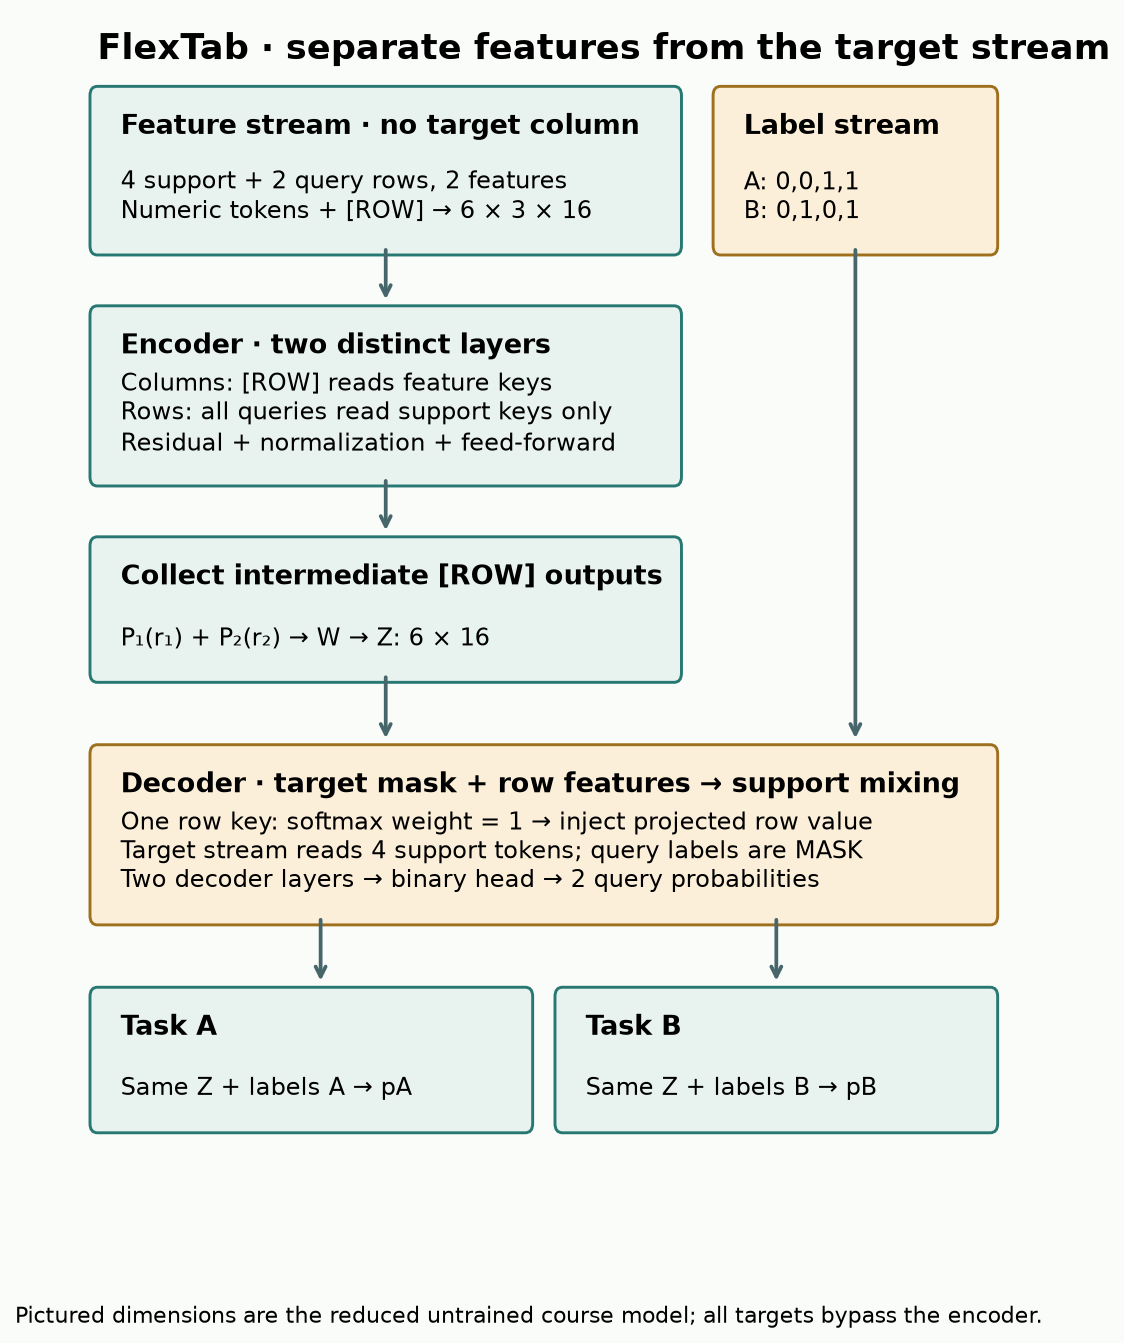

### Follow one row

**Tokenize.** A cell token is a vector encoding a cell’s value. With R rows, C columns and hidden width D, the cell tensor has shape R×C×D; a tensor is simply an array with named axes. Add one learned **[ROW]** token per row to collect its features: R×(C+1)×D. Our six-row, two-column, width 16 example starts as 6×3×16. The full paper also has a batch axis, omitted here for one table.

**Across columns.** Each token issues a query vector Q to compare with key vectors K. Similarity scores become nonnegative weights summing to one through **softmax**, then mix the associated value vectors V. The [ROW] token reads feature keys. Feature tokens cannot read [ROW] as a key in the course implementation.

**Across rows.** Each column position can read only support rows as keys/values. A query still retains its own features through its residual path: a **residual** adds the block input back to its update. But it cannot read a different query row. This makes query batching irrelevant to each other query under this particular mask.

**Across layers.** A layer applies these operations plus a feed-forward transformation. **Layer normalization** rescales a vector using its coordinate mean and variance; the feed-forward network transforms each vector independently. Different depths can encode different information. We collect each depth’s row vector rℓ, apply its own learned linear map Pℓ, sum, then apply a final map W:

`z = W( P₁(r₁) + P₂(r₂) + … + Pₗ(rₗ) )`

The code you read in the notebook implements each operation explicitly. The paper’s larger model uses richer tokenizers and multiple attention heads. The lab’s single-head numeric network isolates the information path; it is not the released model.

### Why one-key attention is a special case

**Worked example.** Give a target token exactly one row-value vector V=[2,−1]. Whatever its query/key similarity score, softmax over a single number equals [1]. The attention output is therefore [2,−1]. The learned value and output projections can transform that vector, and the residual preserves the target token. With two row values [2,−1] and [0,3], scores [0, log 3] instead give weights [.25,.75] and output [.5,2]. Now the query can select among different rows.

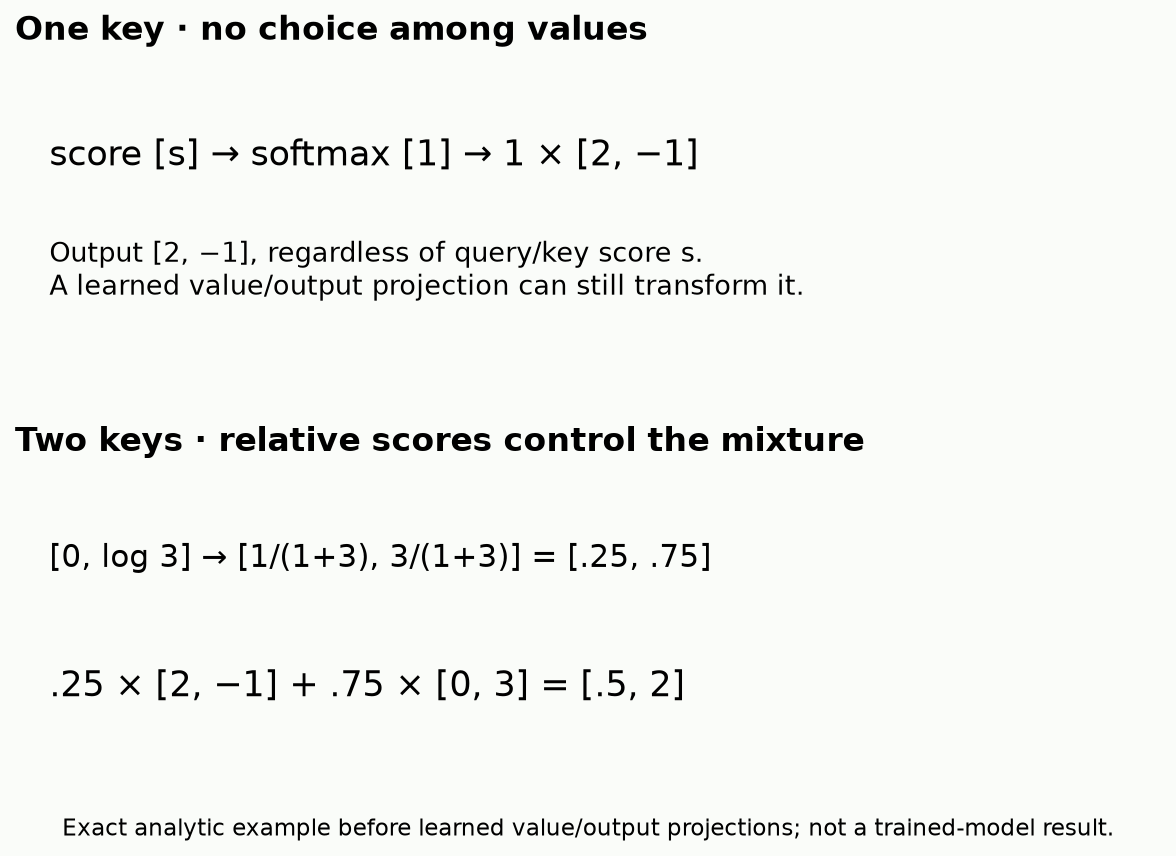

For a single table, the decoder can inject a row embedding through this one-key case and then mix support information along its target stream. For relational prediction, several related row embeddings can become the keys. Their relative weights can matter. [FlexTab Appendix A.2](https://arxiv.org/html/2606.30336v2#A1.SS2)

**Training boundary.** FlexTab first trains its encoder with the classification/regression decoder, then freezes the encoder while training additional task decoders. Its relational decoder learns from partitioned single tables. At inference, related database rows supply its inputs. A feature encoder that excludes the current labels can still have learned from many earlier prediction tasks. [FlexTab §3](https://arxiv.org/html/2606.30336v2#S3)

> **Scope check.** No such training occurs in B17. We inspect random networks at seeds 0/1/2. Their tiny probability changes reveal dependencies, not predictive skill, transfer, anomaly-detection quality or source parity.

## 3 · Predict the intervention, then inspect the measured path

Everything in this control comes from saved float64 forward passes. **Held fixed:** model weights, numeric preprocessing, support size and architecture. **Varied:** exactly the selected labels, features or row order. **Measured:** maximum absolute embedding change and probability change, after aligning rows by ID. A maximum is the largest change across coordinates or query probabilities, not a mean accuracy.

**Notebook intervention:** predict the changes now; the complete live grid is executed after the three TODOs below.

Changing support labels can reuse the feature cache. Changing support features can alter all contextual row representations. Editing q1 alone may change q1; q0 stays unchanged. Reordering support rows together with their labels preserves outputs up to floating-point rounding. Our conservative cache key still changes because it includes order; a cache miss can be harmless extra work.

**Author reference, not current kernel output:**

| Seed | Task | Label edit: max ΔZ | Label edit: max Δprobability | Cache |
|---:|---|---:|---:|---|
| 0 | A | 0 | 0.00001811 | HIT |
| 0 | B | 0 | 0.00002052 | HIT |
| 1 | A | 0 | 0.00004662 | HIT |
| 1 | B | 0 | 0.00000773 | HIT |
| 2 | A | 0 | 0.00002694 | HIT |
| 2 | B | 0 | 0.00002176 | HIT |


These are per-seed mechanism measurements, with no confidence interval: the seeds initialize random wiring, rather than sampling trained model performance. Independent NumPy replay checks all 36 forward records,3456 embedding coordinates and 72 keyed query probabilities. All four possible externally held query-label assignments are checked for each seed/task. Query-label exclusion is enforced structurally by the inference interfaces; those external labels are never arguments to either encoder or decoder.

### A cache is a claim about unchanged dependencies

A **cache key** names the inputs under which a saved result remains valid. For this encoder include feature bytes, ordered row IDs, support membership, preprocessing identity and encoder weights. Include implementation/mask version and precision too. Exclude support labels only because this specific encoder does not read them. A decoder cache would need those labels.

The lab’s `cache_identity` function builds this contract. It hashes complete feature and state bytes rather than only tensor shapes. A **hash** is a compact fingerprint; matching fingerprints are an integrity check, not evidence of good predictions. Changing preprocessing, encoder weights or the support population must invalidate the cached embeddings. Frozen weights alone are insufficient.

For timestamped database predictions, audit **all** information paths. Restricting BFS neighbors to earlier timestamps is insufficient if the table encoder or preprocessing still sees future records. **BFS**, breadth-first search, visits graph neighbors by increasing hop distance. Every cutoff needs a legal feature-context population as well as legal direct neighbors.

## 4 · Model architecture: GTAlign adapts a different boundary

GTAlign converts structural graph representations into inputs for a tabular foundation model. **PCA** projects differing feature widths into a common space; a **GCN** repeatedly mixes neighboring node features. A **community** is a graph partition found from connectivity. Community IDs act as **pseudo-labels**—training targets inferred from structure rather than supplied class annotations. [GTAlign §2](https://arxiv.org/html/2607.11374v1#S2)

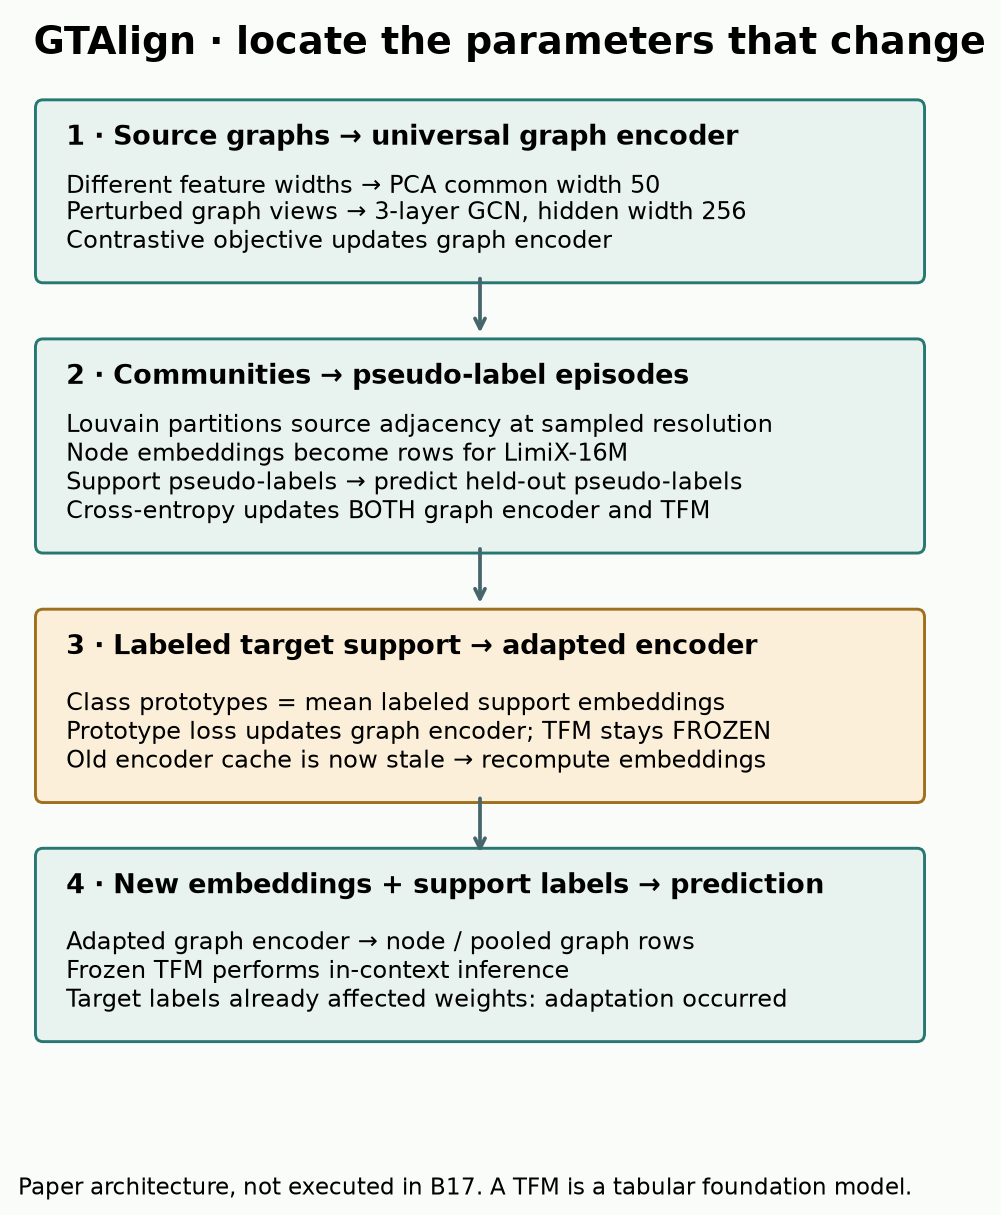

First, contrastive pretraining encourages related graph views to have similar representations. Next, community-based episodes jointly adapt the graph encoder and tabular predictor. Finally, labeled target-domain examples adapt the graph encoder while the tabular predictor stays frozen. The adapted encoder must recompute the embeddings before prediction. [GTAlign §§2.2–2.4](https://arxiv.org/html/2607.11374v1#S2.SS4)

**A prototype** is the mean embedding of a class’s labeled support examples. The target-stage objective encourages embeddings to agree with their class prototypes. This target-label use is adaptation, even though the final predictor uses in-context inference. In-context inference does not imply the entire preceding pipeline was zero-shot.

| Boundary | FlexTab reuse question | GTAlign adaptation question |
|---|---|---|
| Representation input | Table features and encoder context | Node features and graph adjacency |
| Reusable object | Target-free contextual row embeddings | Graph embeddings under a particular encoder |
| Target labels | Enter decoder at inference | Also update graph encoder during adaptation |
| Frozen part | Encoder during specialized decoder training | Tabular predictor during target adaptation |
| Required cache action | Rebuild if features/context/encoder change | Rebuild after encoder adaptation |

**Predict before checking.** If a GTAlign implementation freezes the tabular model but updates the graph encoder, can it reuse embeddings computed before adaptation?

<details><summary>Check your explanation</summary><p>No. The encoder is part of the cached function. Updating its weights changes that function, even when raw node features stay fixed. Recompute support and query embeddings using the adapted encoder.</p></details>

A fair future community-supervision ablation would hold real support labels, source graphs, episode budget and target adaptation fixed while changing only community supervision. B17 does not execute that study. A citation graph and a foreign-key database graph also encode different relationships; success on one cannot establish the other.

## 5 · Full reproduction: a named target and a real stop

The selected target is **B17-FLEXTAB-MULTI-TABLE5-F1-DNF**: the complete `rel-f1/driver-dnf` test task, published AUROC **74.6%**. AUROC measures how often a randomly chosen positive receives a higher score than a negative, with half credit for ties. This is a cited target, not a B17 measurement. [FlexTab Table 5](https://arxiv.org/html/2606.30336v2#S4.T5)

The archived author-linked repository probe returned404; the FlexTab model search returned no matches. We have not authenticated original weights, preprocessing, sampling/seeds, the complete evaluation population or its temporal encoding policy. The gate checks saved source hashes, then refuses a paper run. It cannot create a missing evaluator. GTAlign’s promised release is likewise not authenticated by the name-search results. [Source receipts](https://avistian.github.io/relational/labs/sources/b17/manifest.json) · [Full reproduction contract](https://avistian.github.io/relational/labs/b17-reproduction.md)

| Evidence lane | B17 status |
|---|---|
| Reduced mechanism: three seeds × two tasks × six interventions | COMPLETE_MECHANISM_DIAGNOSTIC |
| Full NumPy forward replay | PASS; independent arithmetic, same saved weights |
| Released-source or historical checkpoint identity | NOT_ESTABLISHED |
| Selected Table 5 F1-DNF inference | INCOMPLETE_SOURCE_PROTOCOL_GATE; NOT_RUN |
| Full pretraining / other paper experiments / GTAlign experiments | NOT_RUN |
| Live Colab / deployment | NOT_CHECKED / NOT_REQUESTED |
| Learner mastery | PENDING_WRITTEN_DEFENSE |

The original context and sampling settings remain in the contract; no smaller model, shorter context or synthetic result replaces the paper run. Approved paid execution is $0. The local numerical budget is 3600 aggregate seconds including retries and checks, under the standing $10 ceiling.



## Implementation contract · PROVIDED / TODO / CHECK

This TierC fixture isolates information flow. No package is imported as the model; all reduced model code appears below. No trainer is hidden: training is NOT_RUN. The paper-specific tokenizers, pretrained weights and specialized relational decoder are not available in this packet. Our numerical forward pass is a mechanism mirror only.

Dimensions: six rows, two columns, width 16; two single-head encoder and decoder layers, FF width32, GELU, pre-LayerNorm eps1e-5; no dropout. Seeds0/1/2, taskA/B and all six interventions are fixed before execution. Tolerance1e-10 for independent arithmetic,1e-12 for invariance. Versions used for author execution appear in the evidence packet; this notebook requires PyTorch and NumPy (already installed in ordinary Colab runtimes). It performs no installs/downloads. The source packet below is embedded.

Make your prediction before running: can changing labels ever invalidate this encoder cache? What changes if the target column itself changes?


In [ ]:
# @colab-bootstrap
# No repository imports; CPU only. Tested with torch2.13.0 and NumPy2.5.0.
import hashlib
import json
import math
import torch
from torch import nn
import unittest
torch.set_num_threads(1)

## PROVIDED · hand-computed behavioral checks

The tests check uniform attention, single-key output, gradients, layer projections and cache invalidation. They do not claim pretrained-model parity.

In [ ]:
class Boundaries(unittest.TestCase):
    def test_attention(self):
        q=torch.tensor([[0.,0.],[1.,-1.]],dtype=torch.float64,requires_grad=True)
        k=torch.tensor([[1.,0.],[0.,1.]],dtype=torch.float64,requires_grad=True)
        v=torch.tensor([[2.,4.],[6.,8.]],dtype=torch.float64,requires_grad=True)
        actual=attention(q,k,v)
        self.assertTrue(torch.equal(actual[0],torch.tensor([4.,6.],dtype=torch.float64)))
        expected=torch.nn.functional.scaled_dot_product_attention(q,k,v)
        torch.testing.assert_close(actual,expected,atol=1e-12,rtol=1e-12)
        for a,b in zip(torch.autograd.grad(actual.sum(),(q,k,v),retain_graph=True),torch.autograd.grad(expected.sum(),(q,k,v))):
            torch.testing.assert_close(a,b,atol=1e-12,rtol=1e-12)
        torch.testing.assert_close(attention(q,k[:1],v[:1]),v[:1].expand(2,-1))
        with self.assertRaises(ValueError):attention(q,k[:0],v[:0])
    def test_aggregation(self):
        a=torch.tensor([[1.,2.]],dtype=torch.float64)
        b=torch.tensor([[3.,4.]],dtype=torch.float64)
        p=[torch.nn.Linear(2,2,bias=False).double() for _ in range(2)]
        f=torch.nn.Linear(2,2,bias=False).double()
        with torch.no_grad():
            p[0].weight.copy_(torch.eye(2));p[1].weight.copy_(2*torch.eye(2));f.weight.copy_(3*torch.eye(2))
        torch.testing.assert_close(aggregate_layers([a,b],p,f),torch.tensor([[21.,30.]],dtype=torch.float64))
        with self.assertRaises(ValueError):aggregate_layers([a],p,f)
    def test_cache(self):
        x=torch.tensor([[1.,2.],[3.,4.]],dtype=torch.float64);state={'w':torch.ones(2)}
        key=cache_identity(x,['s','q'],1,state,'numeric-v1')
        self.assertEqual(key,cache_identity(x.clone(),['s','q'],1,state,'numeric-v1'))
        for args in [(x+1,['s','q'],1,state,'numeric-v1'),(x,['q','s'],1,state,'numeric-v1'),(x,['s','q'],2,state,'numeric-v1'),(x,['s','q'],1,{'w':torch.zeros(2)},'numeric-v1'),(x,['s','q'],1,state,'numeric-v2')]:
            self.assertNotEqual(key,cache_identity(*args))
        with self.assertRaises(ValueError):cache_identity(x,['q','q'],1,state,'numeric-v1')
        with self.assertRaises(ValueError):cache_identity(x,['q'],1,state,'numeric-v1')

## TODO · attention

Compute a scaled QK transpose, normalize over the key axis, and mix values. Reject empty keys. Preserve batched inputs and gradients. Why: an attention mask is an information-access contract, not just a speed trick.

In [ ]:
def attention(q, k, v):
    raise NotImplementedError("Complete attention")

### CHECK · run immediately

Fix the operation before continuing. This function remains live in the model/grid.

In [ ]:
Boundaries('test_attention').debug()
print('attention: CHECK passed')

## TODO · aggregate_layers

Validate one projection per layer. Apply the corresponding linear map to every layer output, sum, then apply the final map. Why: averaging before different projections changes the operation.

In [ ]:
def aggregate_layers(rows, projections, final):
    raise NotImplementedError("Complete aggregate_layers")

### CHECK · run immediately

Fix the operation before continuing. This function remains live in the model/grid.

In [ ]:
Boundaries('test_aggregation').debug()
print('aggregate_layers: CHECK passed')

## TODO · cache_identity

Return a SHA256 fingerprint of features, ordered unique IDs, support size, encoder state, preprocessing and implementation identity. Include tensor shape/dtype and raw bytes. Do not accept labels as inputs. Why: same shape or frozen weights alone cannot establish cache validity. Use implementation tag b17-encoder-v1 and preserve the order in the serialization contract printed below.

For byte-exact report replay, serialize metadata as compact JSON `[ids, support_size, preprocessing, "b17-encoder-v1"]`. Then in order: features followed by sorted state entries. For each tensor append JSON `[name, shape, str(dtype)]` (default separators), then its contiguous CPU NumPy bytes. This fixes serialization, not which dependencies your implementation must validate.

In [ ]:
def cache_identity(x, ids, support_size, state, preprocessing):
    raise NotImplementedError("Complete cache_identity")

### CHECK · run immediately

Fix the operation before continuing. This function remains live in the model/grid.

In [ ]:
Boundaries('test_cache').debug()
print('cache_identity: CHECK passed')

## PROVIDED · Q/K/V and feature encoder

Paper §2.2 and A.1 mechanism: feature-only column keys, support-only row keys and collected layer outputs. The lab chooses numeric embeddings and pre-normalization; no upstream source parity is claimed. Watch where your attention and aggregation functions are called.

In [ ]:
class Attention(nn.Module):
    """Visible single-head Q/K/V/output projections; no attention library."""
    def __init__(self, width):
        super().__init__()
        self.q = nn.Linear(width, width)
        self.k = nn.Linear(width, width)
        self.v = nn.Linear(width, width)
        self.out = nn.Linear(width, width)

    def forward(self, q, kv):
        return self.out(attention(self.q(q), self.k(kv), self.v(kv)))

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.columns = Attention(width)
        self.rows = Attention(width)
        self.norms = nn.ModuleList([nn.LayerNorm(width) for _ in range(3)])
        self.ff = nn.Sequential(nn.Linear(width, 2*width), nn.GELU(), nn.Linear(2*width, width))

    def forward(self, t, support_size):
        # t: [rows, columns+1, width]; last position is [ROW].
        a = self.norms[0](t)
        t = t + self.columns(a, a[:, :-1])  # no feature reads [ROW]
        a = self.norms[1](t).transpose(0, 1)  # [columns+1, rows, width]
        t = t + self.rows(a, a[:, :support_size]).transpose(0, 1)
        return t + self.ff(self.norms[2](t))

In [ ]:
class Encoder(nn.Module):
    def __init__(self, columns=2, width=16, depth=2):
        super().__init__()
        self.numeric = nn.Linear(1, width)
        self.column = nn.Parameter(torch.randn(columns, width)*.1)
        self.row = nn.Parameter(torch.randn(width)*.1)
        self.blocks = nn.ModuleList([EncoderBlock(width) for _ in range(depth)])
        self.projections = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.final = nn.Linear(width, width)

    def forward(self, x, support_size):
        # No labels argument: targets cannot enter encoder inference.
        t = self.numeric(x.unsqueeze(-1)) + self.column
        t = torch.cat([t, self.row.expand(len(x), 1, -1)], dim=1)
        rows = []
        for block in self.blocks:
            t = block(t, support_size)
            rows.append(t[:, -1])
        return aggregate_layers(rows, self.projections, self.final)

## PROVIDED · target decoder

One-key cross-attention injects each row embedding, then target-stream attention reads support labels indirectly through support tokens. Query tokens start with MASK index2. No query-label argument exists. The two tasks share this decoder as well as the encoder; the paper’s specialized task decoders are a separate training stage.

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.features = Attention(width)
        self.targets = Attention(width)
        self.norms = nn.ModuleList([nn.LayerNorm(width) for _ in range(3)])
        self.ff = nn.Sequential(nn.Linear(width, 2*width), nn.GELU(), nn.Linear(2*width, width))

    def forward(self, t, z, support_size):
        # Each target reads its own row embedding (one key); target-stream
        # attention then propagates support information to query targets.
        t = t + self.features(self.norms[0](t).unsqueeze(1), z.unsqueeze(1)).squeeze(1)
        a = self.norms[1](t)
        t = t + self.targets(a, a[:support_size])
        return t + self.ff(self.norms[2](t))

class Decoder(nn.Module):
    def __init__(self, width=16, depth=2):
        super().__init__()
        self.label = nn.Embedding(3, width)  # 0, 1, query MASK=2
        self.blocks = nn.ModuleList([DecoderBlock(width) for _ in range(depth)])
        self.head = nn.Linear(width, 2)

    def forward(self, z, support_labels):
        n = len(support_labels)
        tokens = torch.cat([support_labels, torch.full((len(z)-n,), 2, dtype=torch.long)])
        t = self.label(tokens)
        for block in self.blocks:
            t = block(t, z, n)
        return self.head(t[n:]).softmax(-1)[:, 1]

## PROVIDED · frozen fixture and complete intervention grid

Read all six modes before execution. Save every state and prediction. No choice is made based on outputs. Query-label interventions enumerate all four external binary assignments; these cannot enter the interfaces. A cache stores the encoder output only.

In [ ]:
def fixture():
    x = torch.tensor([[-1,0],[0,1],[1,0],[0,-1],[.5,.5],[-.5,-.5]], dtype=torch.float64)
    return x, ['s0','s1','s2','s3','q0','q1'], {'A':[0,0,1,1], 'B':[0,1,0,1]}

def initialized(seed):
    torch.manual_seed(seed)
    return Encoder().double().eval(), Decoder().double().eval()

In [ ]:
def run_experiment():
    """Run all declared interventions; save enough state for independent replay."""
    torch.set_num_threads(1)
    x, ids, tasks = fixture()
    result = dict(name='B17-REPRESENTATION-BOUNDARY', status='COMPLETE_MECHANISM_DIAGNOSTIC',
                  inputs=x.tolist(), ids=ids, support_size=4, tasks=tasks, seeds=[],
                  precision='float64', training='NOT_RUN', query_labels_reporting_only=[1,0])
    for seed in [0,1,2]:
        enc, dec = initialized(seed)
        state = {name:{k:v.detach().tolist() for k,v in model.state_dict().items()} for name,model in [('encoder',enc),('decoder',dec)]}
        rec = dict(seed=seed, state=state, records=[], checks=[])
        with torch.no_grad():
            z = enc(x,4)
            base_key = cache_identity(x,ids,4,enc.state_dict(),'numeric-v1')
            cached = {base_key:z.clone()}
            for task, values in tasks.items():
                y = torch.tensor(values,dtype=torch.long)
                baseline = dec(z,y)
                for mode in ['baseline','support-labels','support-feature','other-query','support-order','query-order']:
                    changed=x.clone();labels=y.clone();order=list(range(6))
                    if mode=='support-labels':labels=1-labels
                    if mode=='support-feature':changed[0,0]+=2
                    if mode=='other-query':changed[5]=torch.tensor([7.,-3.])
                    if mode=='support-order':order=[2,0,3,1,4,5];labels=labels[order[:4]]
                    if mode=='query-order':order=[0,1,2,3,5,4]
                    changed=changed[order];newids=[ids[i] for i in order]
                    key=cache_identity(changed,newids,4,enc.state_dict(),'numeric-v1')
                    fresh=enc(changed,4);hit=key in cached
                    used=cached[key] if hit else fresh
                    pred=dec(used,labels);direct=dec(fresh,labels)
                    assert torch.allclose(pred,direct,atol=1e-12,rtol=0)
                    aligned_z=fresh[torch.argsort(torch.tensor(order))]
                    q_order=[i-4 for i in order[4:]]
                    aligned_p=pred[torch.argsort(torch.tensor(q_order))]
                    dz=float((aligned_z-z).abs().max());dp=float((aligned_p-baseline).abs().max())
                    if mode in ['baseline','support-labels']:assert dz==0 and hit
                    if mode=='support-labels':assert dp>1e-9
                    if mode=='support-feature':assert dz>1e-9 and not hit
                    if mode=='other-query':
                        assert torch.allclose(fresh[:5],z[:5],atol=1e-12,rtol=0)
                        assert abs(float(pred[0]-baseline[0]))<1e-12
                    if mode in ['support-order','query-order']:assert dz<1e-12 and dp<1e-12
                    rec['records'].append(dict(task=task,mode=mode,inputs=changed.tolist(),ids=newids,
                        support_labels=labels.tolist(),embedding=fresh.tolist(),probability=pred.tolist(),
                        cache_key=key,cache_hit=hit,embedding_delta=dz,prediction_delta=dp,
                        q0_probability=float(aligned_p[0]),cache_fresh_delta=float((pred-direct).abs().max())))
                # All four possible externally held query-label assignments.
                for external in [[0,0],[0,1],[1,0],[1,1]]:
                    assert torch.equal(dec(enc(x,4),y),baseline)
                    rec['checks'].append(dict(task=task,external_query_labels=external,prediction=baseline.tolist(),unchanged=True))
            rec['cache_invalidation']={}
            for mode in ['weights','preprocessing']:
                st={k:v.clone() for k,v in enc.state_dict().items()}
                if mode=='weights':st['numeric.weight'][0,0]+=.1
                key=cache_identity(x,ids,4,st,'numeric-v2' if mode=='preprocessing' else 'numeric-v1')
                rec['cache_invalidation'][mode]=key!=base_key
                assert key!=base_key
        result['seeds'].append(rec)
    return result

## RUN · your live model

Every TODO above contributes to this run. This table now comes from the current kernel, unlike the author-reference table earlier.

In [ ]:
report=run_experiment()
assert len(report['seeds'])==3
print('seed task mode                 max Δembedding   max Δprobability cache')
for s in report['seeds']:
    for v in s['records']:
        print(f"{s['seed']:4} {v['task']:4} {v['mode']:20} {v['embedding_delta']:14.6g} {v['prediction_delta']:16.6g} {'HIT' if v['cache_hit'] else 'MISS'}")
from pathlib import Path
Path('b17-diagnostic.json').write_text(json.dumps(report,indent=2,sort_keys=True)+'\n')

## EXIT · defend the boundary

In150–200 words: explain why encoder output stays fixed under label edits but can change with support features. Derive single-key attention. Identify the GTAlign target-stage trainable component and explain why its old embeddings are stale. Distinguish the course evidence from the published 74.6% AUROC. Ask the teacher for feedback. Revisit in 1/7/30 days; execution is not learner mastery.

In [ ]:
assert sum(len(s['records']) for s in report['seeds'])==36
assert sum(len(s['checks']) for s in report['seeds'])==24
print('COMPLETE_MECHANISM_DIAGNOSTIC; no trained accuracy claim')
print('Paper: INCOMPLETE_SOURCE_PROTOCOL_GATE / NOT_RUN')
print('Learner: PENDING_WRITTEN_DEFENSE')

## Paper-results lane · authenticated source audit, blocked execution

Named target B17-FLEXTAB-MULTI-TABLE5-F1-DNF: full original test population, complete(driverId,date) keys, AUROC0.746. The complete reproduction contract below identifies the missing original assets, context/seeds and temporal scope. Enabling the gate refuses execution until these are recovered; it is not a benchmark launcher. Full pretraining, all other benchmarks and GTAlign experiments remain NOT_RUN. USD 0 paid; author aggregate numerical budget 3600s. Colab frontend NOT_CHECKED.

In [ ]:
import base64,io,zipfile,subprocess,sys
packet=Path('b17-source-packet');packet.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(base64.b64decode('...'))) as archive:
    archive.extractall(packet)
check=subprocess.run([sys.executable,str(packet/'_reproduce_b17.py'),'--phase','audit'],capture_output=True,text=True,check=True)
print(check.stdout)
print((packet/'b17-reproduction.md').read_text())

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(packet/'_reproduce_b17.py'),'--phase','paper'],check=True)
else:
    print('Paper NOT_RUN: original checkpoint, evaluator and temporal sampling protocol unresolved.')